### Code
Before running this notebook, be sure to install `jax_moseq` and its associated dependencies. This notebook also requires `tqdm` and `matplotlib`. Also note that while a GPU is not required, it certainly doesn't hurt.

In [11]:
import jax
import jax.numpy as jnp
import jax.random as jr
import numpy as np

import tensorflow_probability.substrates.jax.distributions as tfd
from dynamax.utils.distributions import NormalInverseWishart
from dynamax.hidden_markov_model.models.gaussian_hmm import GaussianHMM

from jax_moseq.models import warhmm

from tqdm.auto import trange
import matplotlib.pyplot as plt

#### Helper Methods

In [12]:
def print_dict(d, depth=0, ind='  '):
    if type(d) != dict:
        try:
            item = d.shape
        except AttributeError:
            item = d
        print(f'{ind * depth}{item}')
        return

    for k, v in d.items():
        print(f'{ind * depth}{k}')
        print_dict(v, depth + 1, ind)

In [13]:
def plot_ll(key, ll_history):
    plt.title(f'Log Likelihood of {key}')
    plt.xlabel('Iteration')
    plt.ylabel('Log Likelihood')
    plt.plot(ll_history)
    plt.show()

#### Loading the Data
The data is stored in a dictionary with two entries:
- `'x'` - a jax array of shape `(num_sessions, num_timesteps, obs_dim)` containing the continuous observations to which the model will be fit. In this case, these data are 10 dimensional PCA projections of mouse depth images (see Wiltschko et al. 2015) sampled at 30 fps.
- `'mask'` - a jax array of shape `(num_sessions, num_timesteps)` indicating which data points are valid (which is useful in the event that data for each session differs in length).

In [43]:
def random_emissions_and_mask(seed, num_sessions, num_timesteps, num_states, emission_dim, num_mask):
    """Generate random HMM arguments, log-likelihoods, and masking.

    Arguments
        num_timesteps (int): number of timesteps in sequence, T
        num_states (int): number of hmm states, K
        scale (float): covariance scale
        num_mask (int): number of timesteps to mask

    Returns
        hmm (GaussianHMM)
        mask: shape [T]
    """
    seed_init, seed_sample, seed_mask = jr.split(seed, 3)

    hmm = GaussianHMM(num_states, emission_dim, transition_matrix_stickiness=100)
    params, param_props = hmm.initialize(seed_init)

    states, emissions = jax.vmap(hmm.sample, in_axes=(None, 0, None))\
                                (params, jr.split(seed_sample, num_sessions), num_timesteps)

    # Randomly mask sum observations
    mask = jnp.ones((num_sessions, num_timesteps), dtype=int)
    if num_mask > 0:
        i_flip = jax.vmap(jr.randint, in_axes=(0,None, None, None))\
                         (jr.split(seed_mask, num_sessions), (num_mask,), 0, num_timesteps)
        mask = mask.at[i_flip].set(0)

    return (params, param_props), states, emissions, mask

In [48]:
# =======================
# Loading data from file
# =======================

# x_path = 'example_data.npy'
# x = np.load(x_path)

# data = {'x': jax.device_put(x),
#         'mask': jnp.ones((x.shape[:2]))}
# del x

# print_dict(data)

# =========================
# Randomly generating data
# =========================

# TODO Generate data from AR-HMM, as opposed to HMM
# So that the log likelihoods below look okay

num_states = 3
num_sessions = 5
num_timesteps = 100
#num_mask = int(0.20 * num_timesteps)
num_mask = 0
obs_dim = 2
seed = jr.PRNGKey(3420)

hmm_param_and_props, states, emissions, mask \
    = random_emissions_and_mask(seed, num_sessions, num_timesteps, num_states, obs_dim, num_mask)

data = {'x': jax.device_put(emissions),
        'mask': jax.device_put(mask)}

print_dict(data)

x
  (5, 100, 2)
mask
  (5, 100)


#### Setting the Hyperparameters

In [49]:
latent_dim = obs_dim = data['x'].shape[-1]
num_states = 3          # max number of states
nlags = 1                 # number of lags for AR dynamics
possible_taus = jnp.array([1])

trans_hypparams = {
    'gamma': 1e3,
    'alpha': 5.7,
    'kappa': 1e6,
    'num_states':num_states,
    'num_taus':len(possible_taus),
    'tau_stay':0.7
}

ar_hypparams = {
    'S_0_scale': .01,
    'K_0_scale': 10,
    'num_states':num_states,
    'tau_list':possible_taus,
    'nlags':  nlags,
    'latent_dim': latent_dim
}

#### Fitting the Model

In [50]:
model = warhmm.init_model(data,
                          taus=possible_taus,
                         ar_hypparams=ar_hypparams,
                         trans_hypparams=trans_hypparams,
                         verbose=True)

print_dict(model)

T-WARHMM: Initializing hyperparameters
T-WARHMM: Initializing parameters
T-WARHMM: Initializing states
seed
  (2,)
hypparams
  trans_hypparams
    gamma
      1000.0
    alpha
      5.7
    kappa
      1000000.0
    num_states
      3
    num_taus
      1
    tau_stay
      0.7
  ar_hypparams
    S_0_scale
      0.01
    K_0_scale
      10
    num_states
      3
    tau_list
      (1,)
    nlags
      1
    latent_dim
      2
    S_0
      (2, 2)
    K_0
      (3, 3)
    M_0
      (2, 3)
    num_taus
      1
    tau_stay
      0.7
    nu_0
      4
params
  betas_z
    (3,)
  pi_z
    (3, 3)
  betas_t
    (1,)
  pi_t
    (1, 1)
  Ab
    (3, 2, 3)
  Q
    (3, 2, 2)
  possible_taus
    (1,)
states
  z
    (5, 99)
  t
    (5, 99)


In [51]:
model

{'seed': Array([0, 0], dtype=uint32),
 'hypparams': {'trans_hypparams': {'gamma': 1000.0,
   'alpha': 5.7,
   'kappa': 1000000.0,
   'num_states': 3,
   'num_taus': 1,
   'tau_stay': 0.7},
  'ar_hypparams': {'S_0_scale': 0.01,
   'K_0_scale': 10,
   'num_states': 3,
   'tau_list': Array([1], dtype=int32),
   'nlags': 1,
   'latent_dim': 2,
   'S_0': Array([[0.01, 0.  ],
          [0.  , 0.01]], dtype=float32),
   'K_0': Array([[10.,  0.,  0.],
          [ 0., 10.,  0.],
          [ 0.,  0., 10.]], dtype=float32),
   'M_0': Array([[1., 0., 0.],
          [0., 1., 0.]], dtype=float32),
   'num_taus': 1,
   'tau_stay': 0.7,
   'nu_0': 4}},
 'params': {'betas_z': Array([0.32546395, 0.33408144, 0.34045464], dtype=float32),
  'pi_z': Array([[9.9999428e-01, 7.1316907e-07, 5.0106441e-06],
         [8.0421387e-07, 9.9999708e-01, 2.1199917e-06],
         [3.9297305e-07, 2.9121151e-07, 9.9999928e-01]], dtype=float32),
  'betas_t': Array([1.], dtype=float32),
  'pi_t': array([[1.]]),
  'Ab': Array

In [52]:
num_iters = 50    # number of training iterations

ll_keys = ['z', 'x']
ll_history = {key: [] for key in ll_keys}

for i in trange(num_iters):
    # Perform Gibbs resampling
    model = warhmm.resample_model(data, **model)

    # Compute the likelihood of the data and
    # resampled states given the resampled params
    ll = warhmm.model_likelihood(data, **model)
    for key in ll_keys:
        ll_history[key].append(ll[key].item())

  0%|          | 0/50 [00:00<?, ?it/s]

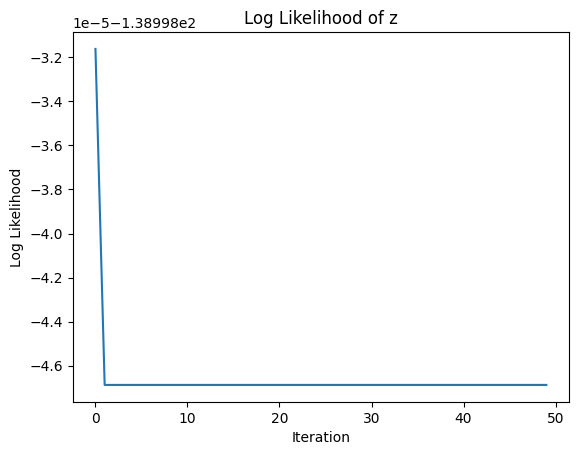

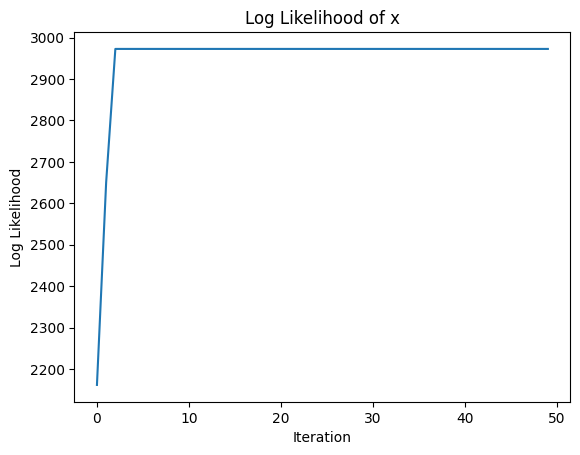

In [53]:
for k, v in ll_history.items():
    plot_ll(k, v)

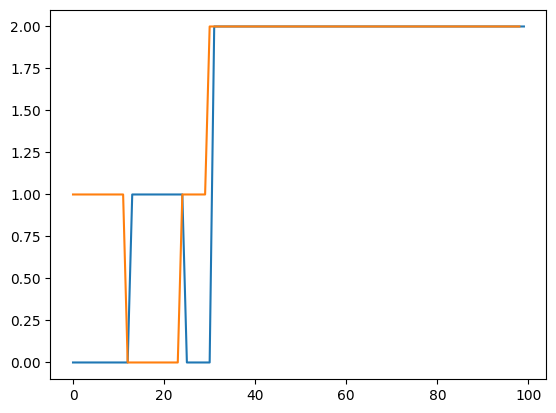

In [63]:
plt.plot(states[2])
plt.plot(model['states']['z'][2])